# Lab 4\. Profiling a Training Loop with the PyTorch Profiler

## Overview

In the chapter you learned that optimization without measurement is guesswork, and that the PyTorch Profiler replaces the guess with evidence: it records how long each operation took, how often it ran, and how much memory it used, then ranks the results so the expensive work is easy to find. Reading a report on a page is one thing; producing one from your own loop and being surprised by it is what turns the idea into a skill. This lab is where you do that.

You will take a small image classifier, wrap its training loop in `torch.profiler.profile`, and configure the profiler to record a few clean steps in the middle of the run. You will generate the summary table, read it column by column, separate the operations that do real work from the ones that merely call other operations, and judge whether the loop is limited by computation or by waiting. You will also export the trace to a file and open it in a timeline viewer, so you can see the run laid out over time rather than only as a table of totals.

The routine you practice here is the one you will use on real models. When a training job is slow, the first productive move is to profile the loop, find the operation at the top of the report, and decide from evidence what to change. Reaching for `torch.compile` or mixed precision comes after that, once you know where the time goes. The synthetic model in this lab keeps the numbers small so the method stays in focus, and the method transfers directly to production-sized workloads.

## Learning Objectives

By the end of this lab, you should be able to:

- Instrument a PyTorch training loop with `torch.profiler.profile` and a recording schedule  
- Enable and interpret `record_shapes` and `profile_memory`  
- Generate the `key_averages` operation table and sort it by time or memory  
- Identify the most time-consuming operations and distinguish self time from total time  
- Use the gap between CPU time and wall time to tell a compute-bound step from a waiting step  
- Export a trace file and view it as a timeline

## Prerequisites

This course’s labs are **not cumulative**, so this lab does not depend on any prior resources or the state of earlier labs if there are any.

You need the following before you start:

- **A notebook environment:** either a Google account for Google Colab, or a local installation of Jupyter Notebook. Every step in this lab runs on a CPU; no GPU is required.  
- **Python 3.12 or later.** On Colab this is already provided. For a local environment, confirm your version with `python --version`.  
- **PyTorch 2.12.1,** installed with `pip` in a previous lab. If you are on Colab, these may already be present.  
- **A web browser** (Chrome, Firefox, or Edge are recommended for Colab).

> **Note:** No GPU is required. The lab detects your hardware and runs on CPU by default. If you happen to have a CUDA GPU available (for example, by enabling the Colab GPU runtime), the same code will use it, and the timing comparison near the end will be more interesting.

## Estimated Time

Approximately 30–40 minutes.

## How to Perform the Exercise

You will work entirely in one notebook, running cells from top to bottom. Create a new notebook in Google Colab (**File \> New notebook**) or a new `.ipynb` in local Jupyter. Download the chapter 4 lab notebook from the [LFD2003-resources GitHub repository](https://github.com/lftraining/LFD2003-resources.git) from the **LFD2003-resources/labs** directory. In Google Colab, select File, then Upload Notebook, and select the chapter 4 lab notebook you downloaded.

Read the explanation before running each cell, run it, and compare what you see to the Sample Output or Output shown after each block. Sample Output means the exact values will differ from run to run (random tensors, dataset counts, file paths), so match the shape and structure rather than every character. Output marks a checkpoint where a specific outcome confirms the step worked.

Commands in this lab use the notebook form, where a line beginning with `!` runs a shell command from inside a notebook cell (for example, `!pip install ...`). If you run these in a local terminal instead of a notebook cell, drop the leading `!`.

> **Note:** Run the cells in order and only once each, unless a step says otherwise. If you restart the notebook's runtime, re-run the cells from the top, because the variables live in memory and are cleared on restart.

## Setup: Environment Preparation

The steps in this section stand up what the later sections need: the imports, a synthetic dataset, and the model from Lab 2\. They are not the learning content of the lab, and on a managed course platform some of them may already be done for you. Run them once at the top of your notebook, then move on to Step 1\.

### Setup 1\. Import Libraries and Select the Device

You begin by importing the modules the lab uses and choosing the device to run on. The profiler lives in `torch.profiler`, and you import the specific helpers now so later cells can use them directly.

> **Note:** In a local environment without PyTorch installed, run `pip install torch torchvision tensorboard` first. In Google Colab these are already available.


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from torch.profiler import profile, schedule, ProfilerActivity, record_function

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)


Sample Output:

```
Using device: cpu
```

The `device` line selects a GPU only if one is available and otherwise uses the CPU, so the same notebook runs unchanged in either environment. On the free Colab CPU runtime you will see `cpu`; on a Colab GPU runtime you would see `cuda`.

### Setup 2\. Define the Model, Data, and Training Pieces

Before you can profile a training loop, you need a loop to profile. You define a small convolutional classifier, a batch of synthetic data to feed it, a loss function, and an optimizer. The model is the same small classifier used as the running example throughout the course: it takes 28-by-28 grayscale images and predicts one of ten classes.

The data here is random rather than a real dataset. That keeps the lab fast and self-contained, and it does not change the profiling method: the profiler measures the operations the loop runs regardless of whether the pixels mean anything.


In [ ]:
class SmallClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2)
        self.relu = nn.ReLU()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x


# Synthetic dataset: 512 random 28x28 grayscale images, 10 classes
num_samples, batch_size = 512, 64
features = torch.randn(num_samples, 1, 28, 28)
labels = torch.randint(0, 10, (num_samples,))
loader = DataLoader(TensorDataset(features, labels), batch_size=batch_size, shuffle=True)

model = SmallClassifier().to(device)
model.train()
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
print("Model, data, loss, and optimizer are ready.")


Output:

```
Model, data, loss, and optimizer are ready.
```

The `DataLoader` hands out batches of 64 images at a time, which is how a real training loop receives data. `CrossEntropyLoss` is the loss the classifier trains against, and `SGD` is the optimizer that applies the gradients. None of these need explanation beyond their role here; the chapter covered why a training loop has these parts.

## Profiling the Training Loop

### Step 1\. Create the Schedule and handler function

The `schedule` decides which steps are actually kept: `wait=1` skips the first step, `warmup=1` runs the next step but discards its measurements so first-run costs do not skew the report, and `active=3` records the three steps after that. Setting `repeat=1` stops after one such cycle. You call `prof.step()` once per iteration so the schedule knows when each step ends.


In [ ]:
profiler_schedule = schedule(wait=1, warmup=1, active=3, repeat=1)

activities = [ProfilerActivity.CPU]
if device == "cuda":
    activities.append(ProfilerActivity.CUDA)

sort_key = "self_cuda_time_total" if device == "cuda" else "self_cpu_time_total"

def trace_handler(prof):
    # Called automatically at the end of the active cycle.
    print(prof.key_averages().table(sort_by=sort_key, row_limit=12))
    prof.export_chrome_trace("trace.json")


The `activities` list tells the profiler what to watch: It will always watch PyTorch operators on the CPU, and on-device kernels as well only when a GPU is present. The `sort_key` selects the self-time column that matches the device, so the same code sorts correctly on CPU or GPU. The `trace_handler` function is what the profiler calls when the active steps finish; it prints the summary table and writes the trace to `trace.json` for later viewing.

### Step 2\. Run the Profiled Loop and Generate the Report

Now you instrument the training loop. Three ideas from the chapter come together in this cell: the profiler context manager, the recording schedule, and labeled code regions.

The context manager `profile(...)` records every PyTorch operation that runs inside its `with` block, namely, the training loop. . Each iteration fetches a batch, runs the forward pass and loss, runs the backward pass, and steps the optimizer

To make the report readable, you wrap each phase of the step using the `record_function`.  context manager. This profiler helper labels a block of code with a name you choose, so that block appears as a single named row in the table. Labeling the data fetch, the forward pass, the backward pass, and the optimizer step lets you compare those phases directly instead of hunting through low-level operation names.

The loop runs for six steps, which is enough for the schedule to skip one, warm up on one, and record three.


In [ ]:
data_iter = iter(loader)

with profile(
    activities=activities,
    schedule=profiler_schedule,
    on_trace_ready=trace_handler,
    record_shapes=True,
    profile_memory=True,
) as prof:
    for step in range(6):
        with record_function("data_loading"):
            inputs, targets = next(data_iter)
            inputs, targets = inputs.to(device), targets.to(device)

        with record_function("forward"):
            outputs = model(inputs)
            loss = loss_fn(outputs, targets)

        with record_function("backward"):
            optimizer.zero_grad()
            loss.backward()

        with record_function("optimizer_step"):
            optimizer.step()

        prof.step()


When the active step (`prof.step()`) completes for the third time (in the fifth iteration, after one skipped and one for warmup), the profiler calls `trace_handler`, which prints a table like the following, sorted by self time. Some columns are omitted here for width, and your exact numbers will differ from run to run and machine to machine.

Sample Output:

```
(some columns omitted for width)
-------------------------------------  ------------  ------------  ------------  ------------
                                 Name      Self CPU     CPU total  CPU time avg    # of Calls
-------------------------------------  ------------  ------------  ------------  ------------
           aten::convolution_backward      19.630ms      19.820ms       3.303ms             6
             aten::mkldnn_convolution      17.499ms      17.737ms       2.956ms             6
             aten::threshold_backward      12.309ms      12.309ms       1.368ms             9
                              forward       2.465ms      56.176ms      18.725ms             3
  aten::max_pool2d_with_indices_back…       2.248ms       6.015ms       1.003ms             6
                             backward       2.163ms      47.099ms      15.700ms             3
                       optimizer_step     194.481us       1.699ms     566.470us             3
                         data_loading     180.926us       3.982ms       1.327ms             3
-------------------------------------  ------------  ------------  ------------  ------------
Self CPU time total: 109.406ms
```

> **Note:** With `profile_memory=True`, the profiler may print a benign warning such as "Memory block of unknown size was allocated before the profiling started." This is expected and does not affect the report; you can ignore it.

`record_shapes=True` tells the profiler to record the input shapes of each operation, and `profile_memory=True` tells it to track memory each operation allocates; you use the memory data in Step 8\. Both options add a little overhead, which is why you enable them deliberately rather than always. Do not read the exact milliseconds as correct or expected values; the shape of the table is what matters, and you interpret it in the next steps.

## Reading the Profiler Report

### Step 3\. Read the key\_averages Table

The table is the profiler's core output, so it is worth reading one column at a time. `Name` is the operation or the labeled region you created. Rows beginning with `aten::` are PyTorch's internal tensor operations; the lowercase names such as `forward` and `data_loading` are your `record_function` labels. `# of Calls` is how many times each ran across the recorded steps, and `CPU time avg` is the average time per call.

The two columns that carry the most weight are `Self CPU` and `CPU total` (since our example is running on CPU). Ask yourself three questions as you read: which operation has the largest self time, whether that matches what you expected for a small convolutional model, and how much of the time the `data_loading` label accounts for compared with `forward` and `backward`. Hold your answers in mind; the next steps explain why the two time columns differ and what the answers tell you.

### Step 4\. Separate Self Time from Total Time

Operations call other operations, and that nesting is why each row shows two times. `CPU total` is the time an operation took including everything it called. `Self CPU` is the time spent in that operation alone, excluding its children.

Look at the sample table with that distinction in mind. The `forward` and `backward` labels show large `CPU total` values, because they contain everything the model does during those phases. Their `Self CPU` is small, because they are wrappers that delegate the real work downward. The operations actually doing the heavy computation are the ones with large `Self CPU`, such as `aten::convolution_backward` and `aten::mkldnn_convolution` (the convolution math) and `aten::threshold_backward` (the activation's backward pass). To rank operations by where work truly happens, sort by self time, which is why the `trace_handler` function we defined used `self_cpu_time_total` as its sort key.

> **Note:** A high `CPU total` with a low `Self CPU` marks a parent that passes work along. A high `Self CPU` marks the operation doing the work. When you look for something to optimize, the self-time column points at the real target.

### Step 5\. Diagnose Compute Versus Waiting

A large time value tells you where execution time is being spent, but interpreting it requires care. CPU time, in the conventional operating-system sense, measures how long the processor was executing work for a process or thread. Wall time, or wall-clock time, is the elapsed time from start to finish, including waiting.. When the two are close, the operation is keeping the CPU busy most of the time and compilation, mixed precision, or a faster kernel might help. When wall time is much larger than CPU time, substantial time is being spent waiting, so optimizing CPU computation alone will not remove that delay. In the profiler table, `Self CPU` is the time attributed directly to an operation, while `CPU total` also includes time spent in child operations that it calls. However, these are not the same thing as comparing processor-active time against wall-clock time. To identify waiting or overlap, the execution timeline (see the “Visualizing the Trace” section) is usually more informative: gaps, long data-loading regions, synchronization points, and periods where one device is idle reveal where execution is stalled rather than doing useful work.

In this lab the `data_loading` label lets you see where input-pipeline time fits into the step. Compare its time against `forward` and `backward`. In this synthetic setup the data already sits in memory as tensors, so `data_loading` is small and the loop is dominated by computation in the convolution. That is itself an instructive result: it tells you that for this model on this data, speeding up computation is the productive path, and optimizing the input pipeline would have little effect. In a real training job that reads images from disk and applies transforms, the same label often tells the opposite story, sitting near the top of the report and revealing a loop that spends substantial time obtaining and preparing data.

> **Key concept:** A slow step is not necessarily limited by computation. Use the profiler table to identify expensive operations and the timeline to distinguish active computation from waiting, synchronization, data movement, and input-pipeline delays.

### Step 6\. Inspect Memory Usage

Because you profiled with `profile_memory=True`, the same recording also captured how much memory each operation allocated. You read it by sorting the table on a memory column instead of a time column. Run this in a new cell after the profiled loop; `prof` still holds the data from the recorded cycle.


In [ ]:
print(prof.key_averages().table(sort_by="self_cpu_memory_usage", row_limit=10))


Sample Output:

```
(some columns omitted for width)
---------------------------------------  ------------  ------------  ------------
                                   Name       CPU Mem  Self CPU Mem    # of Calls
---------------------------------------  ------------  ------------  ------------
                            aten::empty      16.13 Mb      16.13 Mb            30
                        aten::clamp_min      13.88 Mb      13.88 Mb             9
               aten::threshold_backward      13.88 Mb      13.88 Mb             9
  aten::max_pool2d_with_indices_backwa…      13.78 Mb      13.78 Mb             6
          aten::max_pool2d_with_indices      10.34 Mb      10.34 Mb             6
                               aten::mm       3.55 Mb       3.55 Mb            12
                            aten::addmm     103.50 Kb     103.50 Kb             6
---------------------------------------  ------------  ------------  ------------
Self CPU time total: 109.406ms
```

`Self CPU Mem` is the memory an operation allocated on its own, and `CPU Mem` includes memory attributed to its children. Sorting by memory rather than time answers a different question: which operations allocate the most memory, rather than which ones run slowest. This is the view you would use when a model runs out of memory, because it points you at the operations driving the pressure instead of leaving you to guess.

## Visualizing the Trace

### Step 7\. Export a Trace and View It as a Timeline

The table aggregates each operation across the recorded steps, which is what you want for ranking cost. It cannot show you *when* things happened, such as an idle gap where the processor waited between two operations. For that you need a timeline, and `trace_handler` already wrote one to `trace.json` when the profiled loop finished.

To view it, open a trace viewer in your browser and load the file. Perfetto, a web-based trace viewer, reads the file directly at [`https://ui.perfetto.dev`](https://ui.perfetto.dev) (click on the “Open trace file” on the top left); the built-in Chrome viewer at `chrome://tracing` opens the same file. In both, operations are laid out left to right in the order they ran, so repeated stalls, overlapping work, and long pauses become easy to see.

In Colab, download the trace file to your machine first, then load it in the viewer:


In [ ]:
# In Google Colab, download the trace to open it locally in a trace viewer.
from google.colab import files
files.download("trace.json")


> **Note:** In a local Jupyter environment, `trace.json` is already saved in your working directory; skip the Colab download cell and open the file directly in the viewer. The `google.colab` import only works inside Colab.

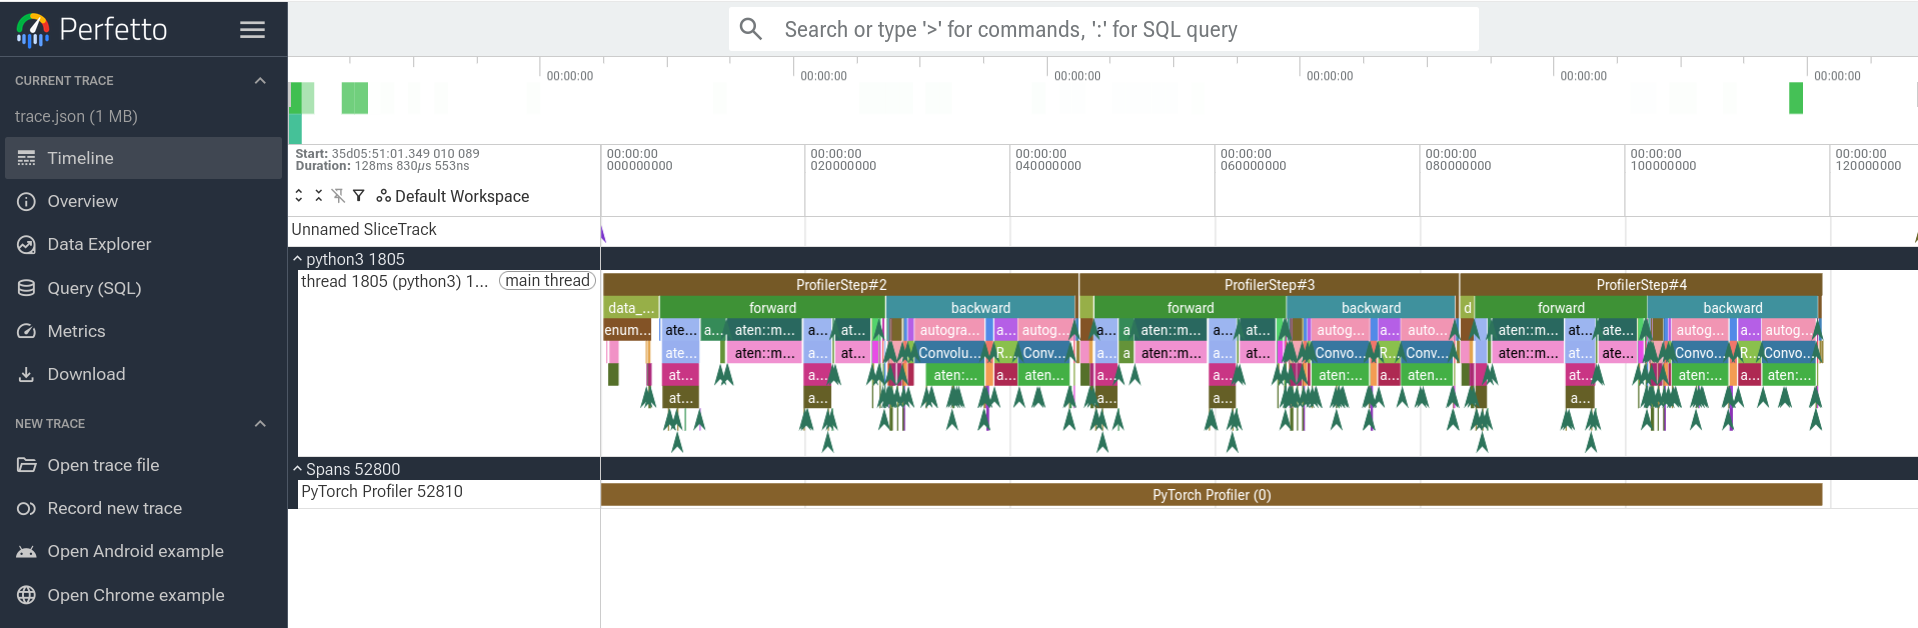

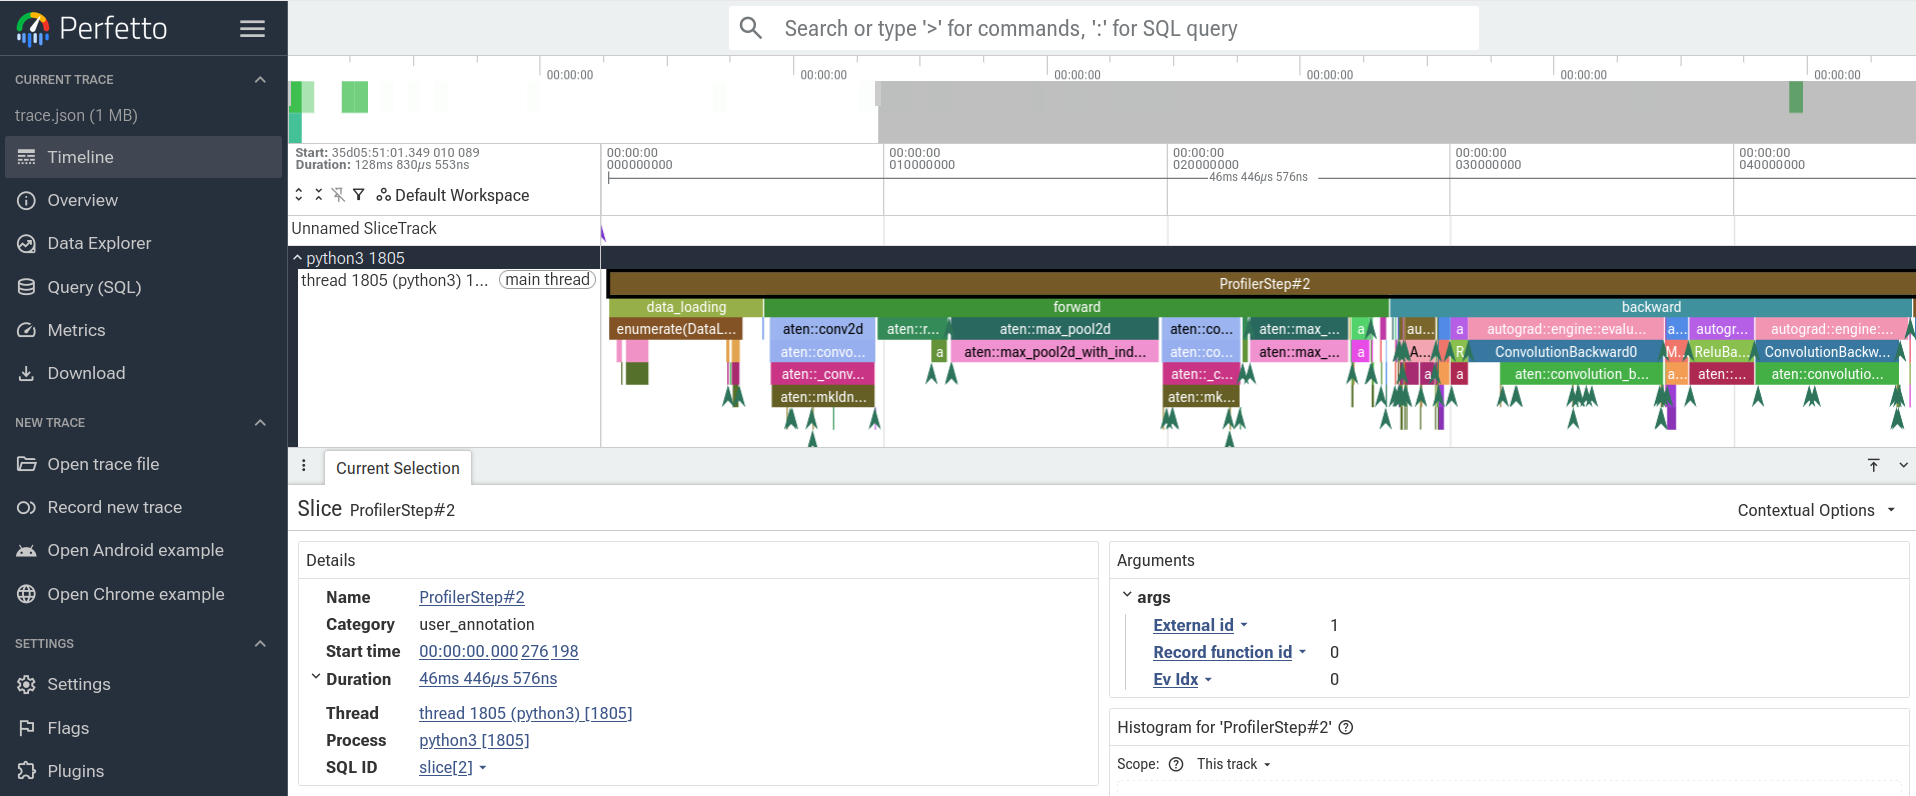

## Cleanup

This lab runs entirely in the notebook session's memory and writes only the `trace.json` file . Nothing persists once the runtime stops, and no later lab depends on anything created here.

To return to a clean state, remove the trace file, then optionally restart the runtime.


In [ ]:
import os

# Remove the trace file
if os.path.exists("trace.json"):
    os.remove("trace.json")

print("Cleanup complete.")


Sample Output:

```
Cleanup complete.
```

On Google Colab the runtime is temporary. When your Colab session ends, all loaded objects are cleared.

## Summary

You instrumented a real training loop with `torch.profiler.profile`, used a `wait`/`warmup`/`active` schedule to record a few clean steps, and enabled `record_shapes` and `profile_memory` to capture the detail you needed. Reading the `key_averages` table, you separated the operations that do the work (high self time) from the wrappers that only call other operations (high total time), and you found the convolution operations at the top of the report for this small model. You used the `data_loading` label to reason about compute versus waiting, saw that this synthetic loop is compute-bound, and learned why the same measurement often points at the input pipeline in a real job. Finally, you exported the trace and viewed it as a timeline, which is where idle gaps and overlap are visible in a way the table cannot show. The diagnostic routine you practiced here — profile first, read the report, then decide what to change — is the one that keeps optimization effort aimed at the operation that actually limits your training speed.

